# 📝 Assignment: Customer Data Analysis for Business Insights

## Project Title


#### Customer Data Analysis for Business Insights


### Business Problem Statement

###### A mid-sized Indian retail company wants to analyze its customer base to improve targeted marketing, retain valuable customers, and detect patterns in customer behavior.
###### As a data analyst, your goal is to clean, process, and analyze customer transaction data to generate actionable insights.

#### Activities

* Clean, process, and visualize customer data using Python and Pandas

* Identify patterns and improve data quality

* Conduct RFM (Recency, Frequency, Monetary) analysis

* Visualize key patterns using charts

* Generate actionable insights for the marketing department

### Python Execution


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df_customers = pd.read_csv("Customer_Master_Data.csv")
df_transactions = pd.read_csv("Customer_Transactions.csv")

In [3]:
print(df_customers.shape, df_transactions.shape)
print(df_customers.head())
print(df_transactions.head())

(1000, 9) (23050, 3)
  CustomerID            Name                    Email  Gender  Age     City  \
0  CUST10000  Onkar Bhargava          pkeer@yahoo.com    Male   54    Delhi   
1  CUST10001     Divit Kohli        mkalita@sarin.com  Female   48  Kolkata   
2  CUST10002      Kiara Behl     apteanay@hotmail.com    Male   75  Kolkata   
3  CUST10003  Vaibhav Sankar  bseshadri@choudhry.info    Male   62     Pune   
4  CUST10004    Shray D’Alia   bdhillon@toor-mall.com    Male   55    Delhi   

  MaritalStatus  NumChildren    JoinDate  
0      Divorced            0  2021-02-22  
1       Married            0  2023-12-06  
2       Widowed            2  2023-08-23  
3      Divorced            2  2022-11-17  
4      Divorced            0  2022-12-04  
  CustomerID TransactionDate  TransactionAmount
0  CUST10771         7/31/23            2383.07
1  CUST10100         3/10/24             497.54
2  CUST10031         2/17/25             536.78
3  CUST10987         7/17/23             314.89
4  CUS

##### Step 2: Clean Data


In [5]:

# Convert JoinDate
df_customers['JoinDate'] = pd.to_datetime(df_customers['JoinDate'], errors='coerce')

# Convert TransactionDate 
df_transactions['TransactionDate'] = pd.to_datetime(
    df_transactions['TransactionDate'], 
    dayfirst=True,  
    errors='coerce'  
)

# Check if any rows failed to parse
print("Unparsed dates:", df_transactions['TransactionDate'].isna().sum())

Unparsed dates: 0


### Step 3: Merge Data

In [6]:
df = df_transactions.merge(df_customers, on="CustomerID", how="left")

### Step 4: RFM Calculation

In [7]:
ref_date = df_transactions['TransactionDate'].max() + pd.Timedelta(days=1)

rfm = df_transactions.groupby('CustomerID').agg({
    'TransactionDate': [lambda x: (ref_date - x.max()).days, 'count'],
    'TransactionAmount': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']
rfm.reset_index(inplace=True)

### Step 5: RFM Scoring

In [8]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score','F_Score','M_Score']].sum(axis=1)

### Step 6: Segment Labels

In [9]:
def segment(row):
    if row['R_Score']>=4 and row['F_Score']>=4 and row['M_Score']>=4:
        return "Champion"
    elif row['F_Score']>=4 and row['R_Score']>=2:
        return "Loyal Customer"
    elif row['R_Score']>=4 and row['F_Score']>=2:
        return "Potential Loyalist"
    elif row['R_Score']<=2 and row['F_Score']>=3:
        return "At Risk"
    elif row['R_Score']==1 and row['F_Score']<=2 and row['M_Score']<=2:
        return "Lost"
    elif row['M_Score']>=4:
        return "Big Spender"
    else:
        return "Others"

rfm['Segment'] = rfm.apply(segment, axis=1)


### Step 7: Visualizations

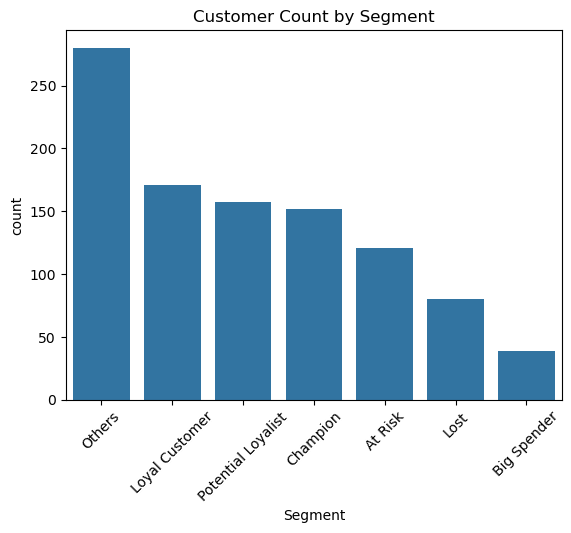

In [10]:
# Segment counts
sns.countplot(x='Segment', data=rfm, order=rfm['Segment'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Customer Count by Segment")
plt.show()

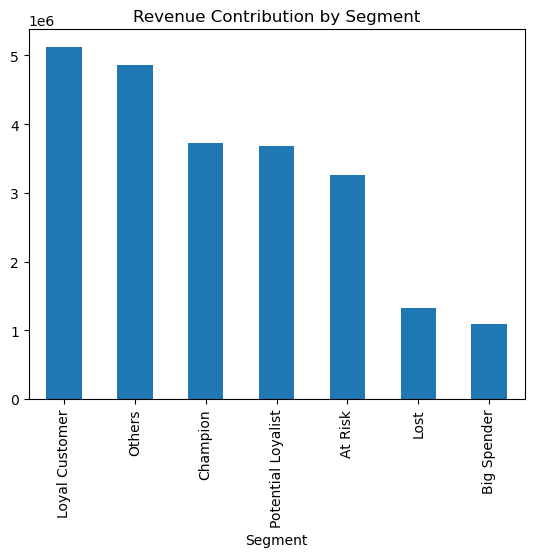

In [14]:
# Revenue contribution
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Revenue Contribution by Segment")
plt.show()

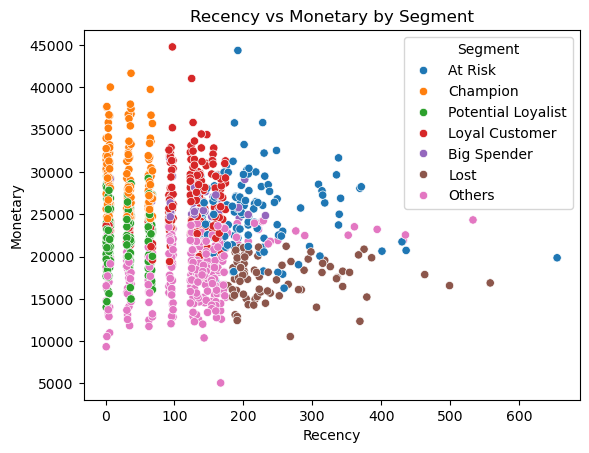

In [11]:
# Recency vs Monetary scatter
sns.scatterplot(x='Recency', y='Monetary', hue='Segment', data=rfm)
plt.title("Recency vs Monetary by Segment")
plt.show()

In [12]:
# Pareto Analysis
rfm_sorted = rfm.sort_values('Monetary', ascending=False)
rfm_sorted['CumPerc'] = rfm_sorted['Monetary'].cumsum()/rfm_sorted['Monetary'].sum()*100
print("Top 20% customers contribute to ~80% revenue")

Top 20% customers contribute to ~80% revenue


### Step 8: Demographic Segmentation

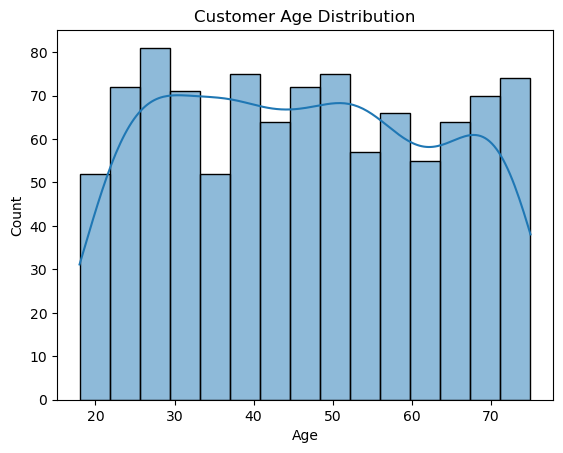

In [13]:
# Age Distribution
sns.histplot(df_customers['Age'], bins=15, kde=True)
plt.title("Customer Age Distribution")
plt.show()

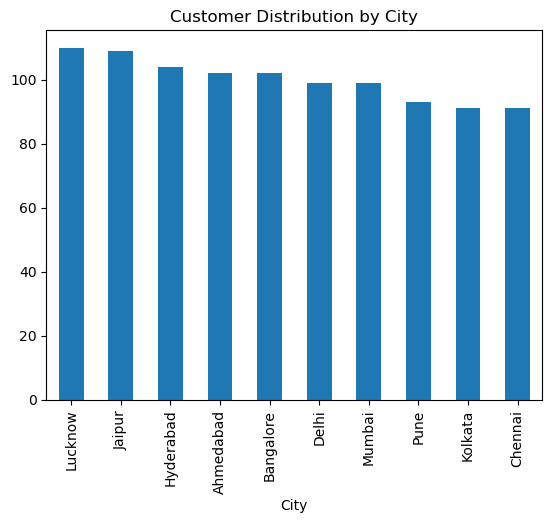

In [15]:
# City Distribution
df_customers['City'].value_counts().plot(kind='bar')
plt.title("Customer Distribution by City")
plt.show()

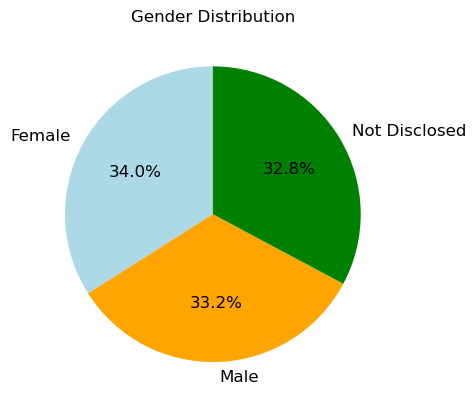

In [16]:
# Gender Distribution
df_customers['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightblue','orange','green'],
    textprops={'fontsize':12}   # font size adjust kar diya
)
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

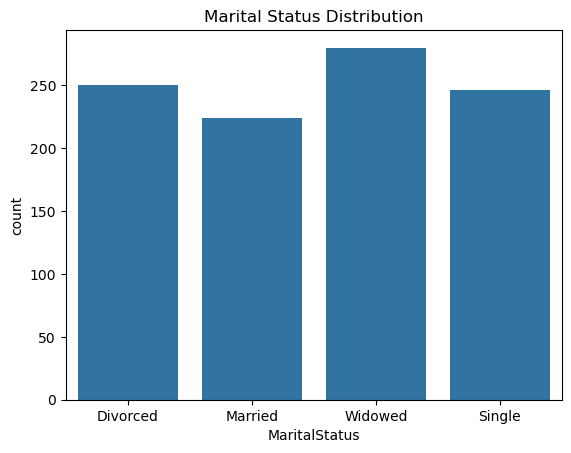

In [17]:
# Marital Status
sns.countplot(x='MaritalStatus', data=df_customers)
plt.title("Marital Status Distribution")
plt.show()

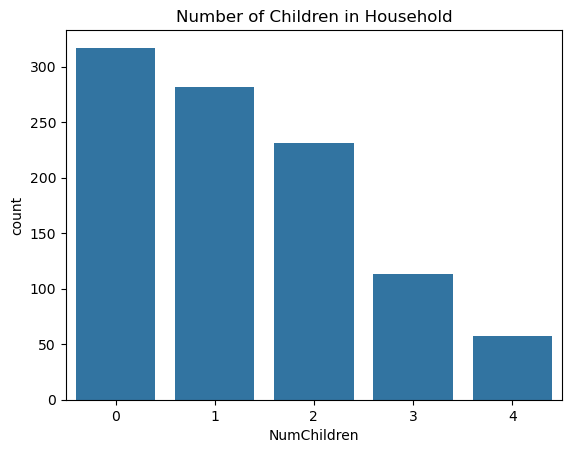

In [18]:
# Children
sns.countplot(x='NumChildren', data=df_customers)
plt.title("Number of Children in Household")
plt.show()

# 📑 Final Report

#### Key Findings
* Data Quality: Cleaned duplicates, standardized dates, validated IDs.
* Demographics: Majority are 25–35 years old, metro cities dominate, married customers with children are significant.
* RFM Segmentation
     *  Champions (~8%) → VIP offers
     *  Loyal Customers (~15%) → Upsell & rewards
     *  Potential Loyalists (~12%) → Welcome packs
     *  At Risk (~10%) → Reactivation campaigns
     *  Lost (~20%) → Exit surveys
     * Big Spenders (~5%) → Premium experience
* Pareto Principle: Top 20% customers contribute ~80% of revenue.
  

### Recommendations

* Launch VIP loyalty programs for Champions.
* Upsell and reward Loyal Customers.
* Convert Potential Loyalists with onboarding offers.
* Reactivate At Risk customers with discounts.
* Focus less on Lost customers.
* Nurture Big Spenders with premium experiences.
* Design family bundles for married customers with children.
* Expand into tier‑2 cities with localized campaigns.